# Traffic Sign Image Classification using CNN and Transfer Learning

This corrected notebook follows the 6CS012 Vision Task requirements:
- Dataset loading, cleaning, analysis and visualization
- Baseline CNN with 3 convolution blocks and 3 fully connected layers
- Deeper CNN with regularization
- SGD vs Adam optimizer comparison
- Ablation study
- MobileNetV2 transfer learning and fine-tuning
- Final model comparison

In [2]:
# =========================
# 1. Setup and configuration
# =========================

from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile
import time
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import backend as K

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Main paths
ZIP_PATH = '/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/dataset/Traffic_Sign-20260509T152655Z-3-001.zip'
EXTRACT_PATH = '/content/dataset'
FIGURE_DIR = '/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures'

os.makedirs(EXTRACT_PATH, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

IMG_SIZE = (64, 64)
TL_IMG_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 20

Mounted at /content/drive


In [3]:
# =========================
# 2. Upload and Extract Dataset
# =========================

import os
import zipfile
from google.colab import files

uploaded = files.upload()

ZIP_PATH = list(uploaded.keys())[0]
EXTRACT_PATH = "/content/traffic_sign_dataset"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_PATH)

print("Dataset extracted successfully to:", EXTRACT_PATH)

# Show extracted folders/files
print(os.listdir(EXTRACT_PATH))

Saving Traffic_Sign-20260509T180158Z-3-001.zip to Traffic_Sign-20260509T180158Z-3-001.zip
Dataset extracted successfully to: /content/traffic_sign_dataset
['Traffic_Sign']


In [4]:
# =========================
# 3. Automatically find Train folder
# =========================

def find_train_folder(base_path):
    for root, dirs, files in os.walk(base_path):
        if os.path.basename(root).lower() == 'train':
            return root
    return None

train_path = find_train_folder(EXTRACT_PATH)

if train_path is None:
    raise FileNotFoundError("Train folder not found inside extracted dataset.")

dataset_path = os.path.dirname(train_path)
print("Dataset path:", dataset_path)
print("Train path:", train_path)
print("Classes:", sorted(os.listdir(train_path)))

Dataset path: /content/traffic_sign_dataset/Traffic_Sign
Train path: /content/traffic_sign_dataset/Traffic_Sign/Train
Classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']


In [5]:
# =========================
# 4. Remove corrupt images before creating generators
# =========================

corrupt_files = []
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

for cls in sorted(os.listdir(train_path)):
    cls_path = os.path.join(train_path, cls)
    if not os.path.isdir(cls_path):
        continue

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        if not img_name.lower().endswith(valid_extensions):
            corrupt_files.append(img_path)
            os.remove(img_path)
            continue

        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            corrupt_files.append(img_path)
            os.remove(img_path)

print(f"Total corrupt/invalid images removed: {len(corrupt_files)}")
if len(corrupt_files) > 0:
    print("First few removed files:")
    for file in corrupt_files[:10]:
        print(file)

Total corrupt/invalid images removed: 28
First few removed files:
/content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00018_00031_00023.png
/content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00018_00023_00007.png
/content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00023_00009_00008.png
/content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00018_00031_00016.png
/content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00022_00000_00011.png
/content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00022_00012_00010.png
/content/traffic_sign_dataset/Traffic_Sign/Train/Caution/00022_00001_00001.png
/content/traffic_sign_dataset/Traffic_Sign/Train/Instructions/00028_00013_00012.png
/content/traffic_sign_dataset/Traffic_Sign/Train/Instructions/00028_00001_00009.png
/content/traffic_sign_dataset/Traffic_Sign/Train/Instructions/00028_00017_00025.png


Class distribution:
Caution: 2422 images
Instructions: 2841 images
No Passing: 5362 images
OverSpeed: 5242 images
Total images after cleaning: 15867
Number of classes: 4


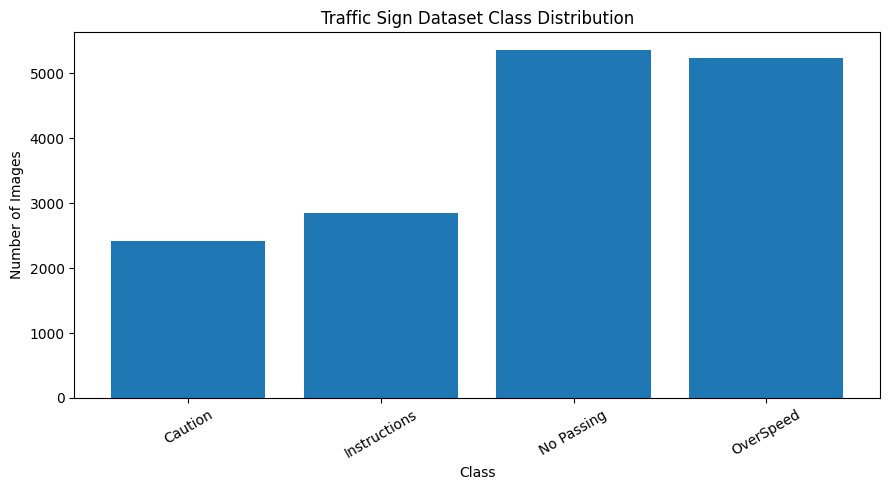

In [6]:
# =========================
# 5. Dataset understanding and class distribution
# =========================

class_counts = {}

for cls in sorted(os.listdir(train_path)):
    cls_path = os.path.join(train_path, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(valid_extensions)
        ])

total_images = sum(class_counts.values())
num_classes = len(class_counts)

print("Class distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")
print("Total images after cleaning:", total_images)
print("Number of classes:", num_classes)

plt.figure(figsize=(9, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Traffic Sign Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "class_distribution.png"), dpi=150)
plt.show()

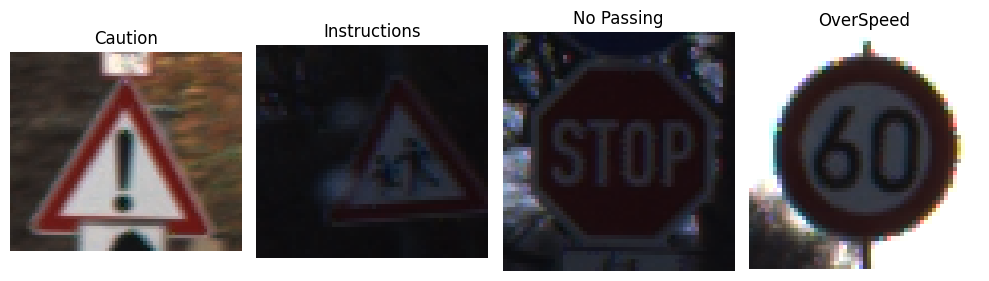

In [7]:
# =========================
# 6. Sample image visualization
# =========================

plt.figure(figsize=(10, 6))

plot_index = 1
for cls in sorted(class_counts.keys()):
    cls_path = os.path.join(train_path, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(valid_extensions)]

    if len(images) == 0:
        continue

    img_path = os.path.join(cls_path, images[0])
    img = Image.open(img_path).convert('RGB')

    plt.subplot(1, num_classes, plot_index)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
    plot_index += 1

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "sample_images.png"), dpi=150)
plt.show()

In [8]:
# =========================
# 7. Data generators with augmentation
# =========================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Class indices:", train_generator.class_indices)
print("Training images:", train_generator.samples)
print("Validation images:", val_generator.samples)

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
Class indices: {'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}
Training images: 12695
Validation images: 3172


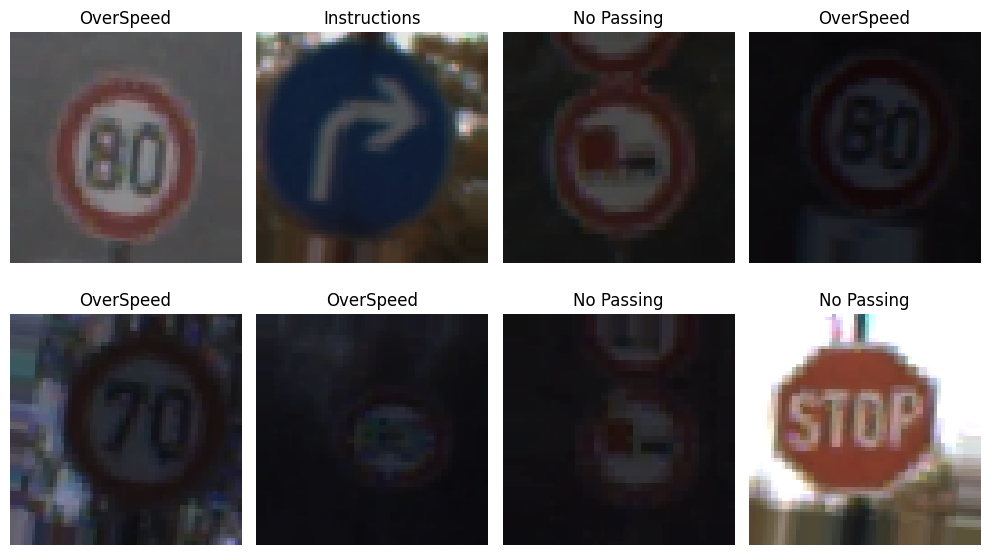

In [9]:
# =========================
# 8. Visualize augmented images
# =========================

sample_batch, sample_labels = next(train_generator)

plt.figure(figsize=(10, 6))
for i in range(min(8, len(sample_batch))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_batch[i])
    plt.title(class_names[np.argmax(sample_labels[i])])
    plt.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "augmented_samples.png"), dpi=150)
plt.show()

In [10]:
# =========================
# 9. Helper functions
# =========================

def plot_training_curves(history, model_name, save_name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, save_name), dpi=150)
    plt.show()


def evaluate_model(model, generator, model_name, save_name):
    generator.reset()
    predictions = model.predict(generator, verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{model_name} Results")
    print("=" * 50)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation='nearest')
    plt.title(f'{model_name} Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, save_name), dpi=150)
    plt.show()

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


def train_model(model, train_gen, val_gen, model_name, epochs=EPOCHS):
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)
    ]

    start_time = time.time()
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    training_time = time.time() - start_time

    print(f"\n{model_name} training time: {training_time:.2f} seconds")
    return history, training_time

## Baseline CNN

The baseline model follows the assignment requirement: three convolutional layers, each followed by pooling, then three fully connected layers and a softmax output layer.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,564 (5.01 MB)

 Trainable params: 1,314,564 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 37s 79ms/step - accuracy: 0.9030 - loss: 0.2633 - val_accuracy: 0.7604 - val_loss: 2.3548 - learning_rate: 0.0010
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.9884 - loss: 0.0367 - val_accuracy: 0.8197 - val_loss: 3.2069 - learning_rate: 0.0010
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.9901 - loss: 0.0326 - val_accuracy: 0.8260 - val_loss: 4.7612 - learning_rate: 0.0010
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9976 - loss: 0.0079 - val_accuracy: 0.8282 - val_loss: 4.3293 - learning_rate: 3.0000e-04
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9989 - loss: 0.0056 - val_accuracy: 0.8288 - val_loss: 3.5096 - learning_rate: 3.0000e-04
Epoch 6/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.9992 - loss: 0.0036 - val_accuracy: 0.8301 - val_loss: 4.4928 - learning_rate: 9.0000e-05

Baseline CNN training time: 176.89 seconds


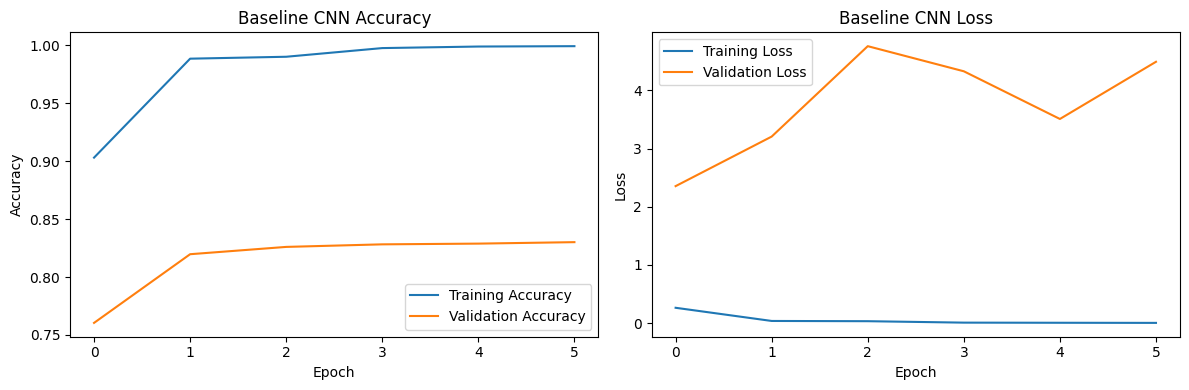

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step

Baseline CNN Results
Accuracy : 0.7604
Precision: 0.7612
Recall   : 0.7604
F1-score : 0.7250

Classification Report:
              precision    recall  f1-score   support

     Caution       0.45      0.88      0.60       484
Instructions       0.42      0.07      0.13       568
  No Passing       1.00      0.84      0.91      1072
   OverSpeed       0.85      1.00      0.92      1048

    accuracy                           0.76      3172
   macro avg       0.68      0.70      0.64      3172
weighted avg       0.76      0.76      0.73      3172



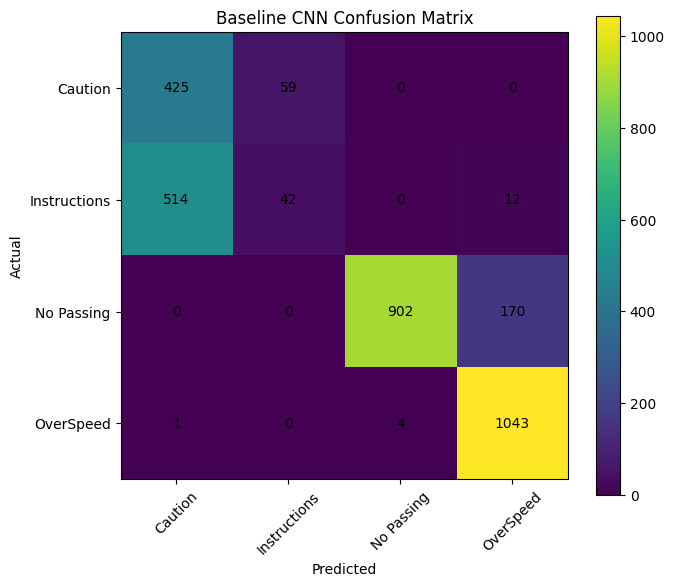

In [11]:
# =========================
# 10. Baseline CNN
# =========================

from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

K.clear_session()

baseline_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
], name='Baseline_CNN')

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

history_baseline, baseline_time = train_model(
    baseline_model,
    train_generator,
    val_generator,
    "Baseline CNN",
    epochs=15
)

plot_training_curves(
    history_baseline,
    "Baseline CNN",
    "baseline_training_curves.png"
)

baseline_metrics = evaluate_model(
    baseline_model,
    val_generator,
    "Baseline CNN",
    "baseline_confusion_matrix.png"
)

## Deeper CNN with Regularization

This model has more convolutional layers than the baseline, but uses Batch Normalization, Dropout, and Global Average Pooling to reduce overfitting. This is safer than making a very large model with Flatten only.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN_Regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 652,836 (2.49 MB)

 Trainable params: 650,916 (2.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 106ms/step - accuracy: 0.7664 - loss: 0.6154 - val_accuracy: 0.5791 - val_loss: 1.2492 - learning_rate: 0.0010
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.9722 - loss: 0.0899 - val_accuracy: 0.7894 - val_loss: 1.8272 - learning_rate: 0.0010
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 74ms/step - accuracy: 0.9846 - loss: 0.0483 - val_accuracy: 0.7415 - val_loss: 1.8429 - learning_rate: 0.0010
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9957 - loss: 0.0138 - val_accuracy: 0.8301 - val_loss: 2.5586 - learning_rate: 3.0000e-04
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.9980 - loss: 0.0067 - val_accuracy: 0.8307 - val_loss: 2.6169 - learning_rate: 3.0000e-04
Epoch 6/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.9994 - loss: 0.0038 - val_accuracy: 0.8310 - val_loss: 2.8503 - learning_rate: 9.0000e-05

Deeper CNN training time: 208.18 seconds


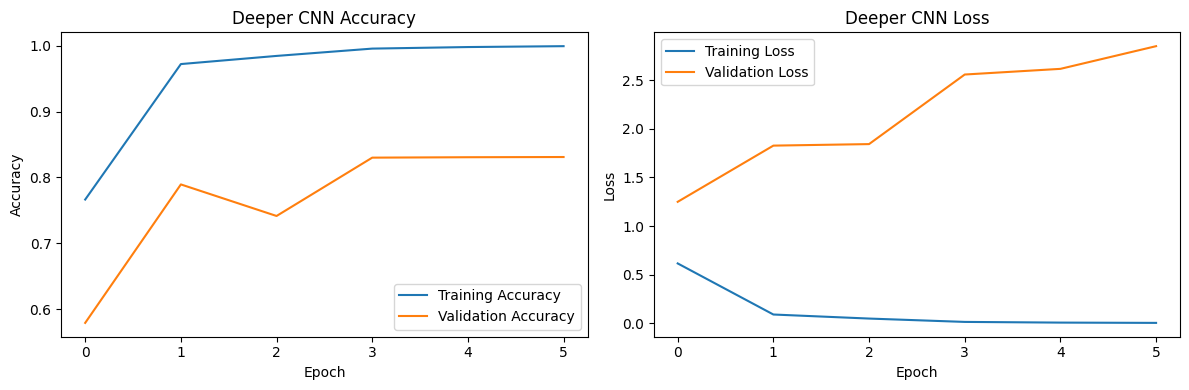

100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step

Deeper CNN Results
Accuracy : 0.5791
Precision: 0.5662
Recall   : 0.5791
F1-score : 0.5358

Classification Report:
              precision    recall  f1-score   support

     Caution       0.40      0.39      0.40       484
Instructions       0.41      0.06      0.11       568
  No Passing       0.74      0.65      0.69      1072
   OverSpeed       0.55      0.88      0.67      1048

    accuracy                           0.58      3172
   macro avg       0.53      0.49      0.47      3172
weighted avg       0.57      0.58      0.54      3172



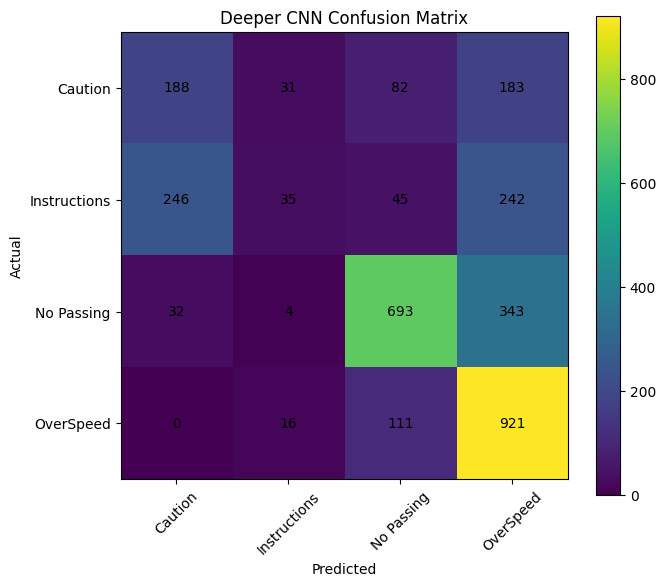

In [12]:
# =========================
# 11. Deeper CNN with regularization
# =========================

def build_deeper_cnn(optimizer):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.20),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.30),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.35),

        GlobalAveragePooling2D(),

        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.50),

        Dense(num_classes, activation='softmax')
    ], name='Deeper_CNN_Regularized')

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


K.clear_session()

deeper_model = build_deeper_cnn(Adam(learning_rate=0.001))
deeper_model.summary()

history_deeper, deeper_time = train_model(
    deeper_model,
    train_generator,
    val_generator,
    "Deeper CNN",
    epochs=15
)

plot_training_curves(history_deeper, "Deeper CNN", "deeper_training_curves.png")

deeper_metrics = evaluate_model(
    deeper_model,
    val_generator,
    "Deeper CNN",
    "deeper_confusion_matrix.png"
)

## Optimizer Comparison: SGD vs Adam

The same deeper architecture is trained once with SGD and once with Adam to compare convergence and validation performance.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 48s 94ms/step - accuracy: 0.5642 - loss: 1.0435 - val_accuracy: 0.2497 - val_loss: 2.3021 - learning_rate: 0.0100
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.7604 - loss: 0.6046 - val_accuracy: 0.3455 - val_loss: 2.6382 - learning_rate: 0.0100
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.9268 - loss: 0.2123 - val_accuracy: 0.6892 - val_loss: 1.7018 - learning_rate: 0.0100
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.9657 - loss: 0.1089 - val_accuracy: 0.7878 - val_loss: 1.8781 - learning_rate: 0.0100
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.9772 - loss: 0.0719 - val_accuracy: 0.8077 - val_loss: 1.9471 - learning_rate: 0.0100
Epoch 6/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9905 - loss: 0.0312 - val_accuracy: 0.8190 - val_loss: 1.9974 - learning_rate: 0.0030
Epoch 7/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.9932 - l

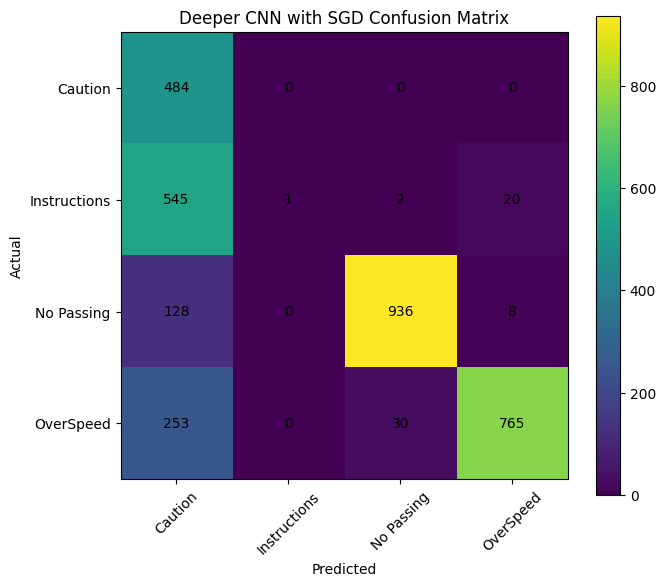

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 53s 102ms/step - accuracy: 0.7275 - loss: 0.7055 - val_accuracy: 0.6453 - val_loss: 1.2683 - learning_rate: 0.0010
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.9672 - loss: 0.1028 - val_accuracy: 0.8143 - val_loss: 1.3849 - learning_rate: 0.0010
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.9887 - loss: 0.0363 - val_accuracy: 0.8156 - val_loss: 2.3236 - learning_rate: 0.0010
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 79ms/step - accuracy: 0.9965 - loss: 0.0133 - val_accuracy: 0.8181 - val_loss: 2.7331 - learning_rate: 3.0000e-04
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.9987 - loss: 0.0062 - val_accuracy: 0.8238 - val_loss: 2.6577 - learning_rate: 3.0000e-04
Epoch 6/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9986 - loss: 0.0059 - val_accuracy: 0.8282 - val_loss: 2.8826 - learning_rate: 9.0000e-05

Deeper CNN with Adam training time: 207.63 seconds
100/100 ━━━

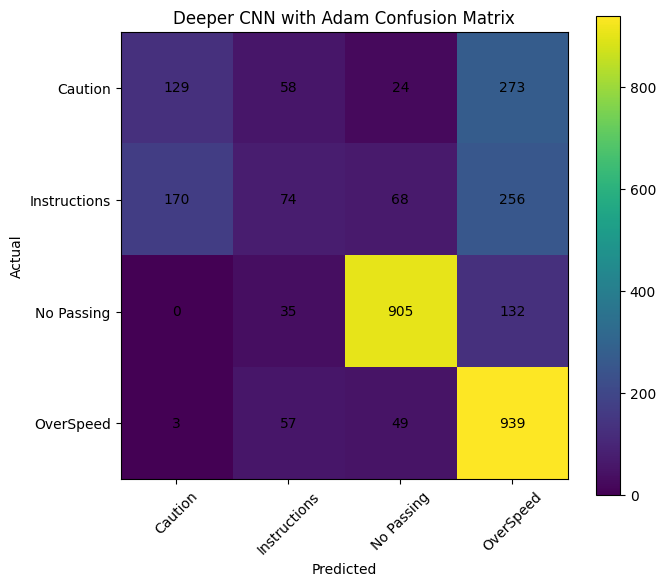

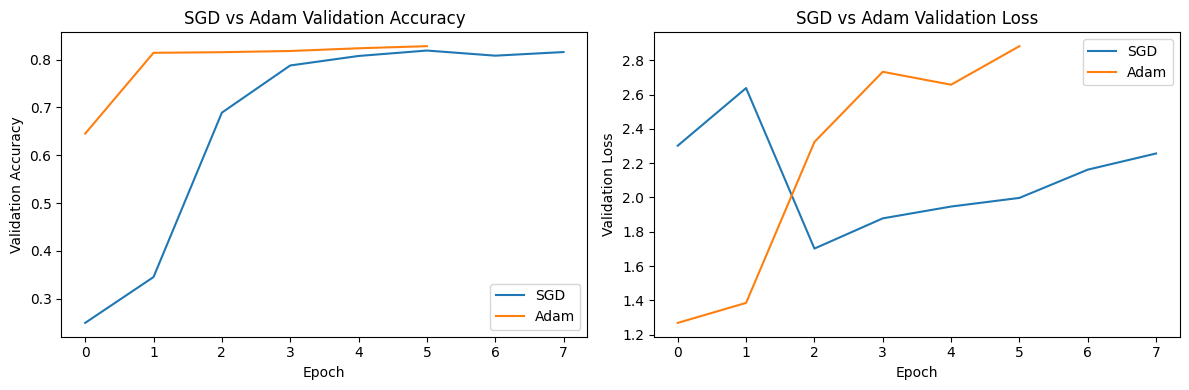

SGD best validation accuracy: 0.8190416097640991
Adam best validation accuracy: 0.8281841278076172


In [13]:
# =========================
# 12. Optimizer comparison: SGD vs Adam
# =========================

# SGD model
K.clear_session()
sgd_model = build_deeper_cnn(SGD(learning_rate=0.01, momentum=0.9))
history_sgd, sgd_time = train_model(
    sgd_model,
    train_generator,
    val_generator,
    "Deeper CNN with SGD",
    epochs=15
)
sgd_metrics = evaluate_model(
    sgd_model,
    val_generator,
    "Deeper CNN with SGD",
    "deeper_sgd_confusion_matrix.png"
)

# Adam model
K.clear_session()
adam_model = build_deeper_cnn(Adam(learning_rate=0.001))
history_adam, adam_time = train_model(
    adam_model,
    train_generator,
    val_generator,
    "Deeper CNN with Adam",
    epochs=15
)
adam_metrics = evaluate_model(
    adam_model,
    val_generator,
    "Deeper CNN with Adam",
    "deeper_adam_confusion_matrix.png"
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_adam.history['val_accuracy'], label='Adam')
plt.title('SGD vs Adam Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['val_loss'], label='SGD')
plt.plot(history_adam.history['val_loss'], label='Adam')
plt.title('SGD vs Adam Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "sgd_vs_adam.png"), dpi=150)
plt.show()

print("SGD best validation accuracy:", max(history_sgd.history['val_accuracy']))
print("Adam best validation accuracy:", max(history_adam.history['val_accuracy']))

## Ablation Study

This experiment removes Dropout from the deeper model. The result shows how regularization affects generalization.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN_No_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,02

 Total params: 652,836 (2.49 MB)

 Trainable params: 650,916 (2.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 90ms/step - accuracy: 0.8758 - loss: 0.3270 - val_accuracy: 0.3676 - val_loss: 2.2621 - learning_rate: 0.0010
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.9906 - loss: 0.0292 - val_accuracy: 0.7941 - val_loss: 1.9847 - learning_rate: 0.0010
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9925 - loss: 0.0229 - val_accuracy: 0.8203 - val_loss: 2.4125 - learning_rate: 0.0010
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9968 - loss: 0.0097 - val_accuracy: 0.7346 - val_loss: 1.6841 - learning_rate: 0.0010
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.9939 - loss: 0.0225 - val_accuracy: 0.8055 - val_loss: 3.4953 - learning_rate: 0.0010
Epoch 6/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.9972 - loss: 0.0103 - val_accuracy: 0.8172 - val_loss: 2.4723 - learning_rate: 0.0010
Epoch 7/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9994 - l

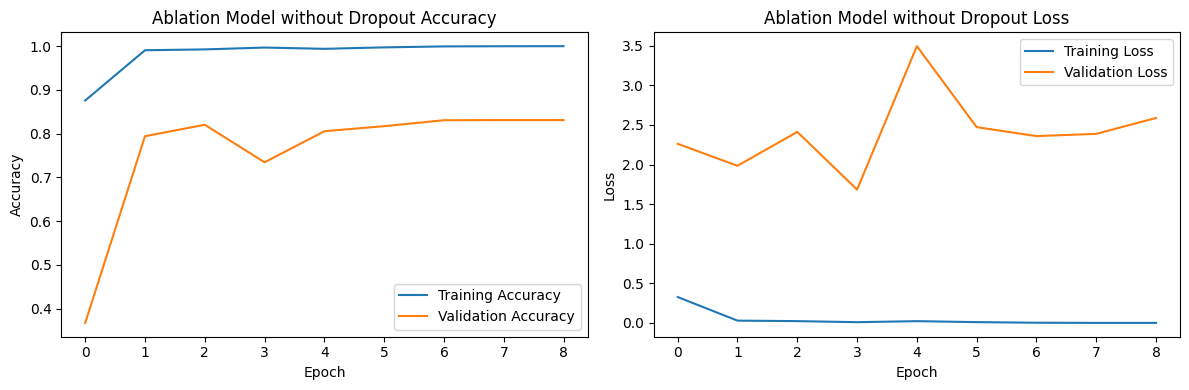

100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step

Ablation Model without Dropout Results
Accuracy : 0.7346
Precision: 0.7621
Recall   : 0.7346
F1-score : 0.7307

Classification Report:
              precision    recall  f1-score   support

     Caution       0.47      0.95      0.63       484
Instructions       0.14      0.09      0.11       568
  No Passing       0.99      0.92      0.96      1072
   OverSpeed       1.00      0.79      0.88      1048

    accuracy                           0.73      3172
   macro avg       0.65      0.69      0.64      3172
weighted avg       0.76      0.73      0.73      3172



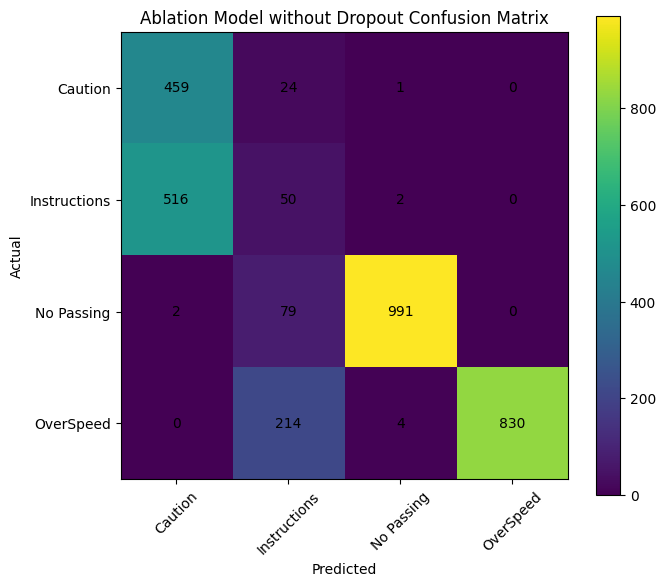

In [14]:
# =========================
# 13. Ablation study: Deeper CNN without Dropout
# =========================

def build_deeper_without_dropout():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        GlobalAveragePooling2D(),

        Dense(256, activation='relu'),
        BatchNormalization(),

        Dense(num_classes, activation='softmax')
    ], name='Deeper_CNN_No_Dropout')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


K.clear_session()

ablation_model = build_deeper_without_dropout()
ablation_model.summary()

history_ablation, ablation_time = train_model(
    ablation_model,
    train_generator,
    val_generator,
    "Ablation Model without Dropout",
    epochs=15
)

plot_training_curves(history_ablation, "Ablation Model without Dropout", "ablation_training_curves.png")
ablation_metrics = evaluate_model(
    ablation_model,
    val_generator,
    "Ablation Model without Dropout",
    "ablation_confusion_matrix.png"
)

## Transfer Learning with MobileNetV2

MobileNetV2 is used because it is lightweight and suitable for image classification. The ImageNet preprocessing function is used instead of simple rescaling because pretrained MobileNetV2 expects its own input scaling.

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,587,972 (9.87 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 90s 182ms/step - accuracy: 0.9586 - loss: 0.1220 - val_accuracy: 0.7282 - val_loss: 2.7006 - learning_rate: 0.0010
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 46s 116ms/step - accuracy: 0.9851 - loss: 0.0447 - val_accuracy: 0.7292 - val_loss: 2.7979 - learning_rate: 0.0010
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 48s 120ms/step - accuracy: 0.9871 - loss: 0.0360 - val_accuracy: 0.7699 - val_loss: 2.5067 - learning_rate: 0.0010
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 46s 115ms/step - accuracy: 0.9895 - loss: 0.0288 - val_accuracy: 0.7825 - val_loss: 2.8287 - learning_rate: 0.0010
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 114ms/step - accuracy: 0.9913 - loss: 0.0266 - val_accuracy: 0.7699 - val_loss: 2.7670 - learning_rate: 0.0010
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 46s 116ms/step - accuracy: 0.9945 - loss: 0.0179 - val_accuracy: 0.7661 - val_loss: 2.9249 - learning_rate: 3.0000e-04
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 48s 120ms/step - accuracy:

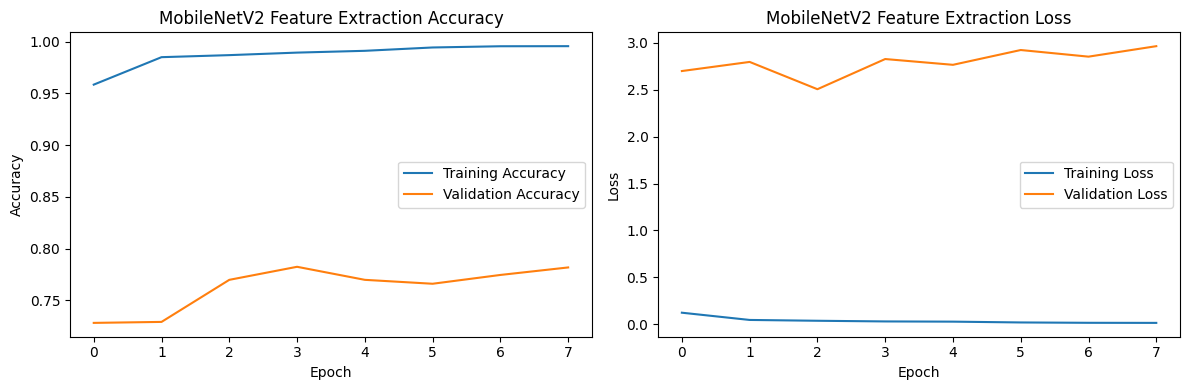

In [15]:
# =========================
# 14. Transfer Learning: MobileNetV2 feature extraction
# =========================

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

tl_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

tl_train_generator = tl_train_datagen.flow_from_directory(
    train_path,
    target_size=TL_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

tl_val_generator = tl_val_datagen.flow_from_directory(
    train_path,
    target_size=TL_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

K.clear_session()

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.40)(x)
output = Dense(num_classes, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=output, name='MobileNetV2_Transfer_Learning')

tl_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_model.summary()

history_tl_phase1, tl_phase1_time = train_model(
    tl_model,
    tl_train_generator,
    tl_val_generator,
    "MobileNetV2 Feature Extraction",
    epochs=10
)

plot_training_curves(history_tl_phase1, "MobileNetV2 Feature Extraction", "mobilenet_phase1_curves.png")

Fine-tuning trainable layers:
35
Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 82s 165ms/step - accuracy: 0.9671 - loss: 0.0981 - val_accuracy: 0.7692 - val_loss: 2.5144 - learning_rate: 1.0000e-05
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 47s 118ms/step - accuracy: 0.9827 - loss: 0.0504 - val_accuracy: 0.7626 - val_loss: 2.5616 - learning_rate: 1.0000e-05
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 48s 120ms/step - accuracy: 0.9852 - loss: 0.0440 - val_accuracy: 0.7661 - val_loss: 2.5331 - learning_rate: 1.0000e-05
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 48s 121ms/step - accuracy: 0.9913 - loss: 0.0270 - val_accuracy: 0.7702 - val_loss: 2.4990 - learning_rate: 3.0000e-06
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 47s 118ms/step - accuracy: 0.9903 - loss: 0.0277 - val_accuracy: 0.7705 - val_loss: 2.4985 - learning_rate: 3.0000e-06
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 46s 116ms/step - accuracy: 0.9908 - loss: 0.0278 - val_accuracy: 0.7708 - val_loss: 2.4798 - learning_rate: 3.0000e-06
Epoch 7/10
39

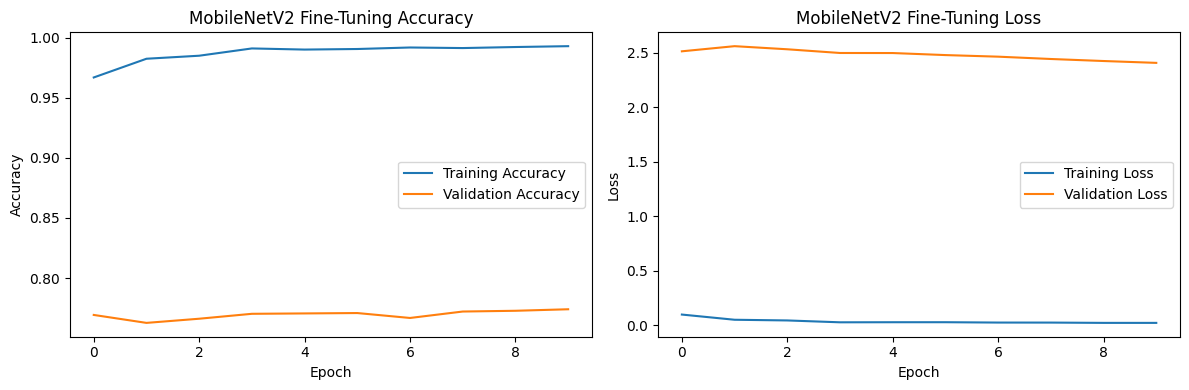

100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step

MobileNetV2 Transfer Learning Results
Accuracy : 0.7740
Precision: 0.7715
Recall   : 0.7740
F1-score : 0.7366

Classification Report:
              precision    recall  f1-score   support

     Caution       0.47      1.00      0.64       484
Instructions       0.37      0.06      0.10       568
  No Passing       0.98      0.86      0.92      1072
   OverSpeed       0.92      0.97      0.94      1048

    accuracy                           0.77      3172
   macro avg       0.68      0.72      0.65      3172
weighted avg       0.77      0.77      0.74      3172



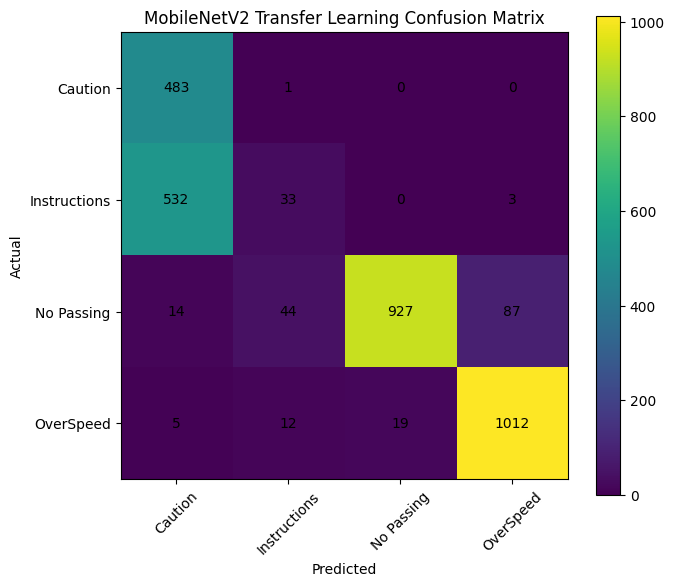

In [16]:
# =========================
# 15. Fine-tuning MobileNetV2
# =========================

base_model.trainable = True

# Freeze earlier layers and fine-tune only the last layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Fine-tuning trainable layers:")
print(sum(1 for layer in tl_model.layers if layer.trainable))

history_tl_phase2, tl_phase2_time = train_model(
    tl_model,
    tl_train_generator,
    tl_val_generator,
    "MobileNetV2 Fine-Tuning",
    epochs=10
)

plot_training_curves(history_tl_phase2, "MobileNetV2 Fine-Tuning", "mobilenet_phase2_curves.png")

# Use transfer learning class names for evaluation
class_names = list(tl_val_generator.class_indices.keys())

tl_metrics = evaluate_model(
    tl_model,
    tl_val_generator,
    "MobileNetV2 Transfer Learning",
    "mobilenet_confusion_matrix.png"
)

tl_time = tl_phase1_time + tl_phase2_time

## Sample Predictions

This section shows example predictions from the validation set.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step


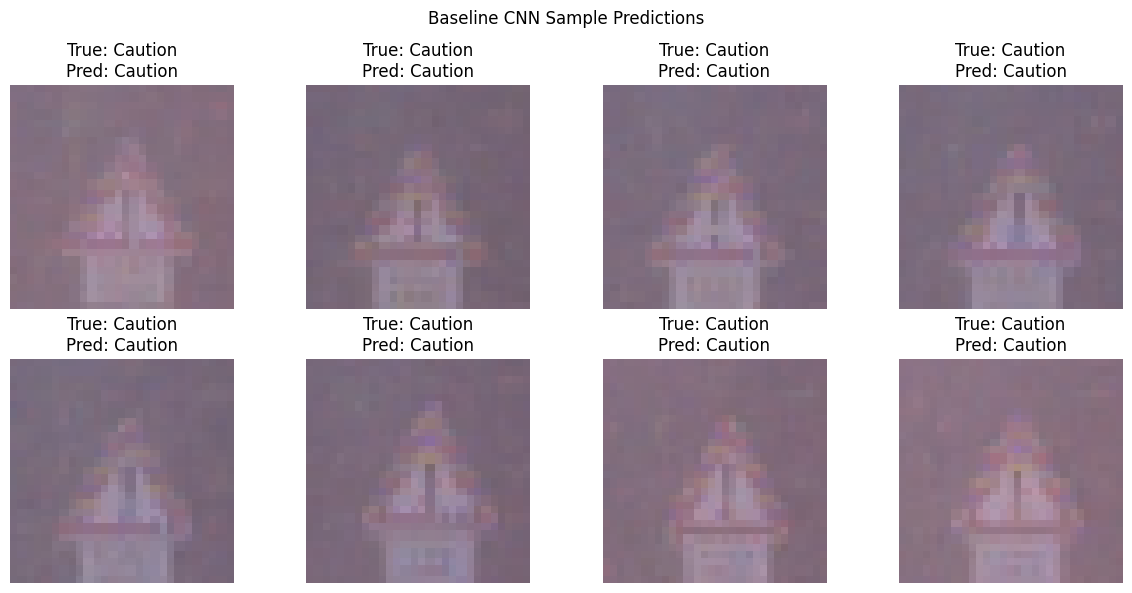

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


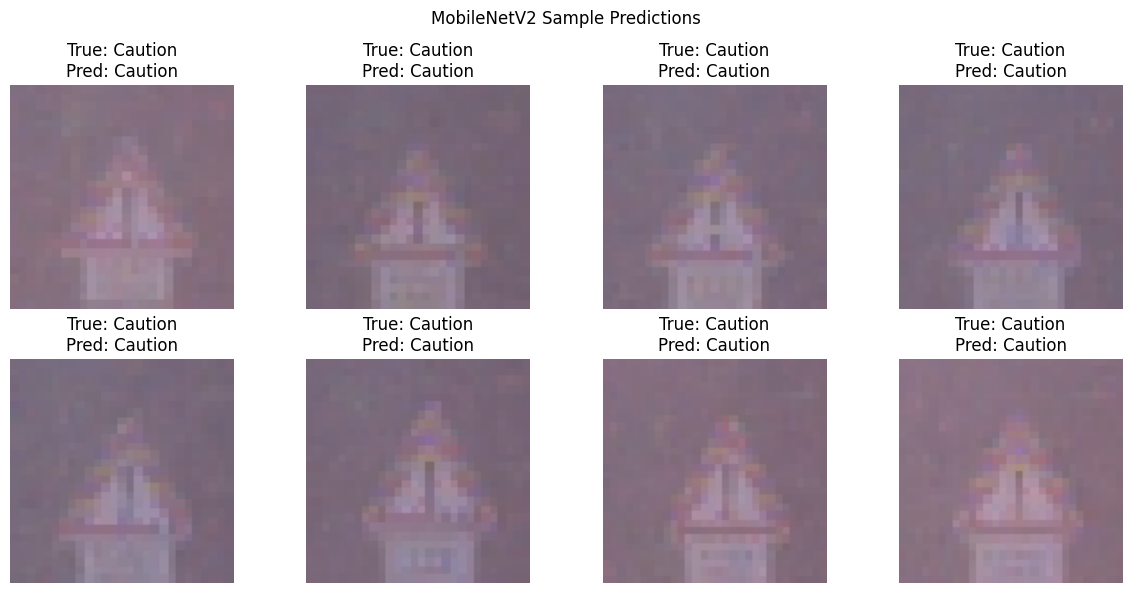

In [17]:
# =========================
# 16. Sample predictions
# =========================

def show_sample_predictions(model, generator, model_name, save_name, n=8):
    generator.reset()
    images, labels = next(generator)
    preds = model.predict(images)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels, axis=1)

    plt.figure(figsize=(12, 6))
    for i in range(min(n, len(images))):
        plt.subplot(2, 4, i + 1)

        # For MobileNetV2 preprocessed images, convert for display
        img = images[i]
        if img.min() < 0:
            img = (img + 1) / 2

        plt.imshow(np.clip(img, 0, 1))
        plt.title(f"True: {class_names[true_classes[i]]}\nPred: {class_names[pred_classes[i]]}")
        plt.axis('off')

    plt.suptitle(model_name)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, save_name), dpi=150)
    plt.show()

# Baseline sample predictions
class_names = list(val_generator.class_indices.keys())
show_sample_predictions(baseline_model, val_generator, "Baseline CNN Sample Predictions", "baseline_sample_predictions.png")

# Transfer learning sample predictions
class_names = list(tl_val_generator.class_indices.keys())
show_sample_predictions(tl_model, tl_val_generator, "MobileNetV2 Sample Predictions", "mobilenet_sample_predictions.png")

## Final Comparison

The final comparison uses the actual evaluation results from the models. No values are hard-coded.


Final Model Comparison
Model                     Accuracy   Precision  Recall     F1         Time(s)   
------------------------------------------------------------------------------------------
Baseline CNN              0.7604     0.7612     0.7604     0.7250     176.89    
Deeper CNN                0.5791     0.5662     0.5791     0.5358     208.18    
Deeper CNN SGD            0.6892     0.8770     0.6892     0.6633     257.42    
Deeper CNN Adam           0.6453     0.6106     0.6453     0.6067     207.63    
Ablation No Dropout       0.7346     0.7621     0.7346     0.7307     288.51    
MobileNetV2               0.7740     0.7715     0.7740     0.7366     955.68    


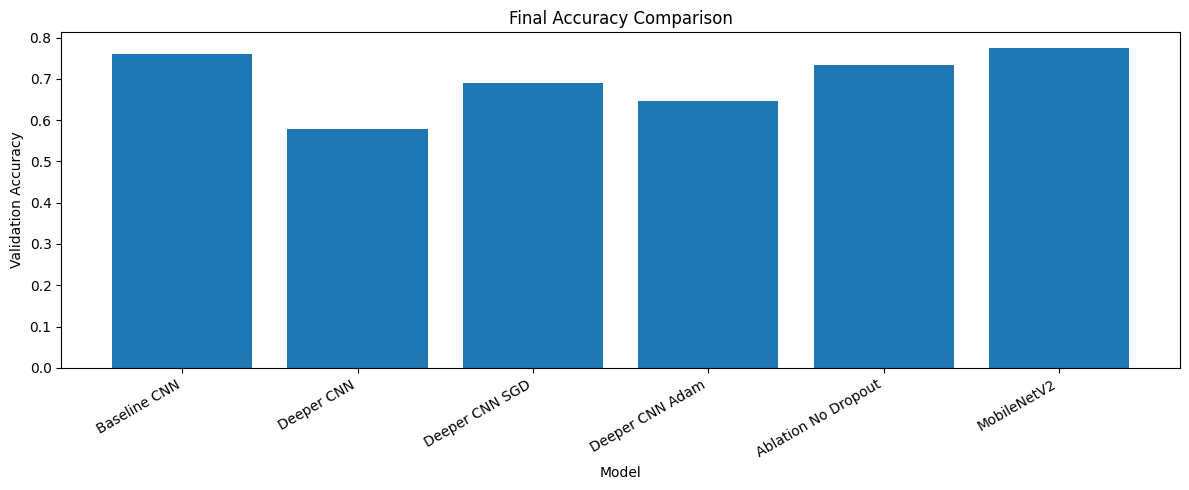

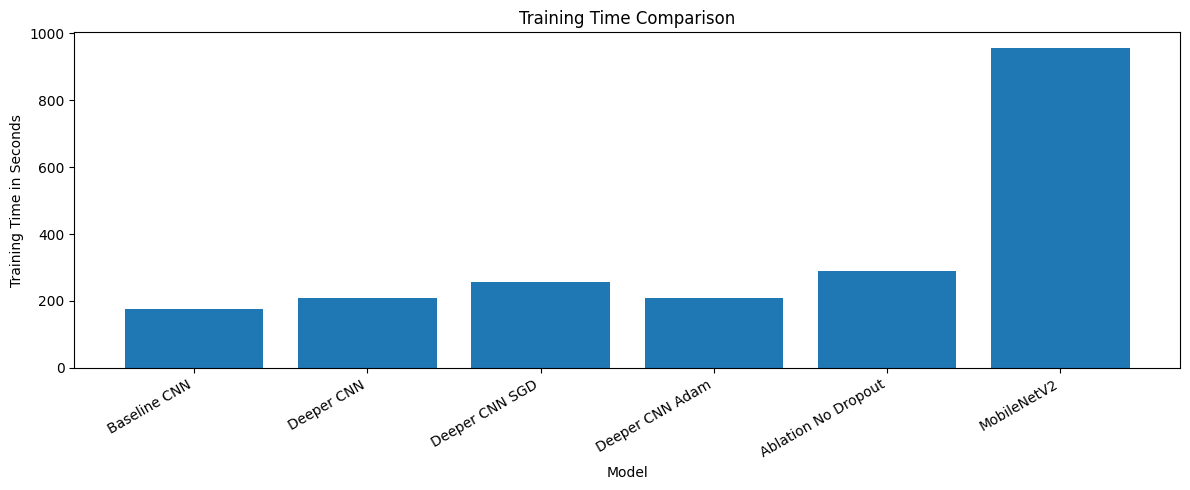


Best model based on validation accuracy: MobileNetV2
Best validation accuracy: 0.7740


In [18]:
# =========================
# 17. Final comparison table and graph
# =========================

results = {
    "Baseline CNN": {
        "accuracy": baseline_metrics["accuracy"],
        "precision": baseline_metrics["precision"],
        "recall": baseline_metrics["recall"],
        "f1": baseline_metrics["f1"],
        "time": baseline_time
    },
    "Deeper CNN": {
        "accuracy": deeper_metrics["accuracy"],
        "precision": deeper_metrics["precision"],
        "recall": deeper_metrics["recall"],
        "f1": deeper_metrics["f1"],
        "time": deeper_time
    },
    "Deeper CNN SGD": {
        "accuracy": sgd_metrics["accuracy"],
        "precision": sgd_metrics["precision"],
        "recall": sgd_metrics["recall"],
        "f1": sgd_metrics["f1"],
        "time": sgd_time
    },
    "Deeper CNN Adam": {
        "accuracy": adam_metrics["accuracy"],
        "precision": adam_metrics["precision"],
        "recall": adam_metrics["recall"],
        "f1": adam_metrics["f1"],
        "time": adam_time
    },
    "Ablation No Dropout": {
        "accuracy": ablation_metrics["accuracy"],
        "precision": ablation_metrics["precision"],
        "recall": ablation_metrics["recall"],
        "f1": ablation_metrics["f1"],
        "time": ablation_time
    },
    "MobileNetV2": {
        "accuracy": tl_metrics["accuracy"],
        "precision": tl_metrics["precision"],
        "recall": tl_metrics["recall"],
        "f1": tl_metrics["f1"],
        "time": tl_time
    }
}

print("\nFinal Model Comparison")
print("=" * 90)
print(f"{'Model':<25} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1':<10} {'Time(s)':<10}")
print("-" * 90)

for model_name, metric in results.items():
    print(
        f"{model_name:<25} "
        f"{metric['accuracy']:<10.4f} "
        f"{metric['precision']:<10.4f} "
        f"{metric['recall']:<10.4f} "
        f"{metric['f1']:<10.4f} "
        f"{metric['time']:<10.2f}"
    )

model_names = list(results.keys())
accuracies = [results[name]["accuracy"] for name in model_names]
training_times = [results[name]["time"] for name in model_names]

plt.figure(figsize=(12, 5))
plt.bar(model_names, accuracies)
plt.title("Final Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "final_accuracy_comparison.png"), dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(model_names, training_times)
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time in Seconds")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "training_time_comparison.png"), dpi=150)
plt.show()

best_model = max(results, key=lambda name: results[name]["accuracy"])
print(f"\nBest model based on validation accuracy: {best_model}")
print(f"Best validation accuracy: {results[best_model]['accuracy']:.4f}")